In [ ]:
import pandas as pd
df = pd.read_csv("Titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


There are missing values in:    

Age - 177

Cabin - 687

Embarked - 2

- We will drop Cabin column as it contains over 77% missing data
- For Age, we will fill values using median as it is less sentitive to outliers.
- For Embarked, we will fill missing values with mode

In [ ]:
df.drop(columns=['Cabin'], inplace=True)

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Now there is no missing values in datset.

Q1. Create a countplot to show the number of passengers by gender.
- Male passengers are more than female passengers.



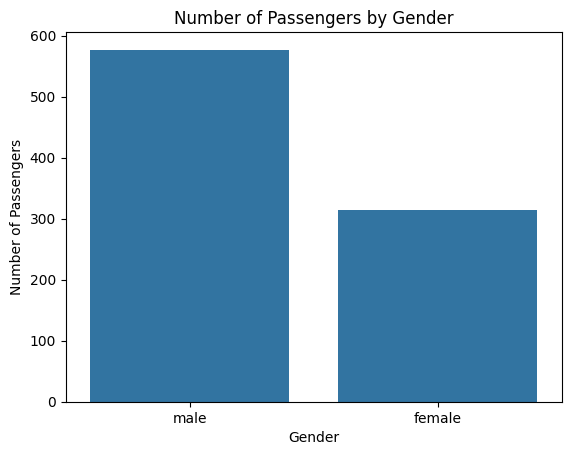

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")

sns.countplot(x="sex", data=titanic)

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.title("Number of Passengers by Gender")

plt.show()

Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.
- Class 3 has highest number of passengers, followed by Class 1 and Class 2.

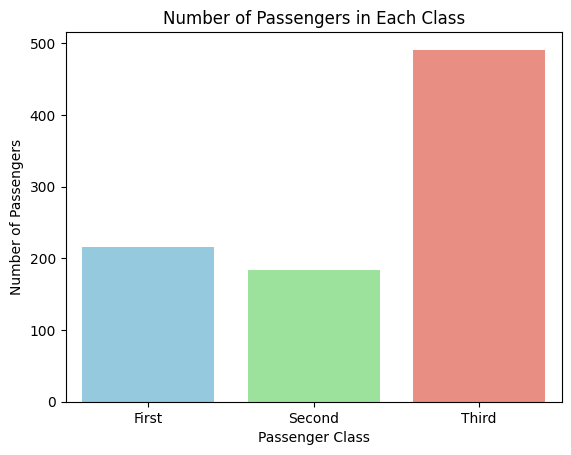

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")

sns.countplot(
    x="class",
    hue="class",
    data=titanic,
    palette=["skyblue", "lightgreen", "salmon"],
    legend=False
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Number of Passengers in Each Class")

plt.show()

Q3. Create a histogram to show the distribution of passenger age.
- The distribution is approximately normal but skewed right.
- A large concentration of passengers is between the ages of 20 and 40.
- There is noticeable spike for young children ages 0-5.


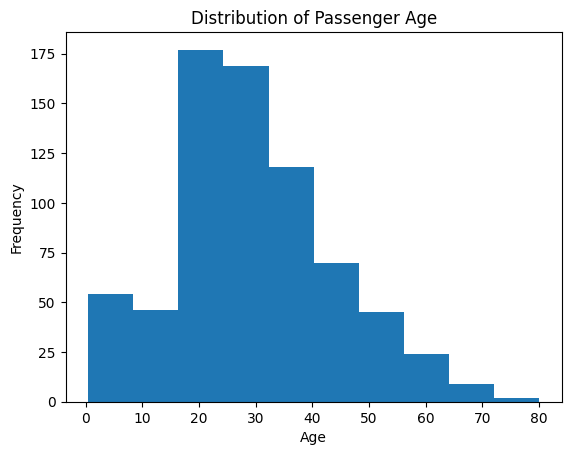

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['Age'], bins = 10)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Passenger Age")

plt.show()

Q4. Create a boxplot to detect outliers in the fare column.


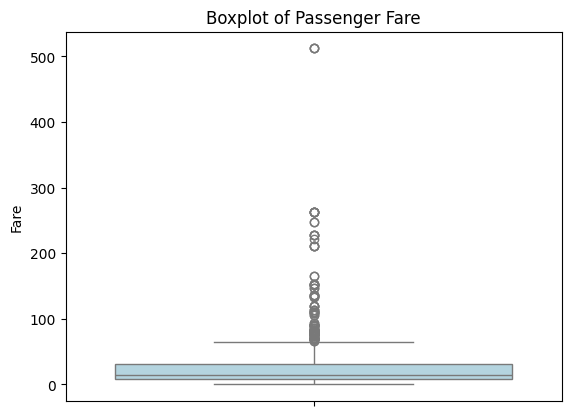

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")

sns.boxplot(
    y="fare",
    data=titanic,
    color="lightblue"
)

plt.ylabel("Fare")
plt.title("Boxplot of Passenger Fare")

plt.show()

Q5. Create a scatterplot to

 a. show the relationship between age and fare.

 b. analyze the relationship between family size (SibSp + Parch) and fare.

 - Individual travelers and smaller families span the entire range of ticket prices, including the most expensive first-class luxury tickets.

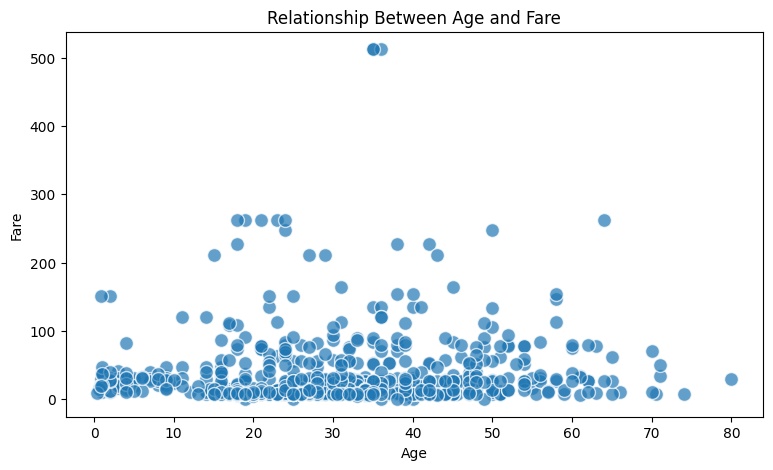

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.scatter(df['Age'], df['Fare'], s = 100, alpha=0.7, edgecolors = 'white', linewidth = 1)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Relationship Between Age and Fare")

plt.show()

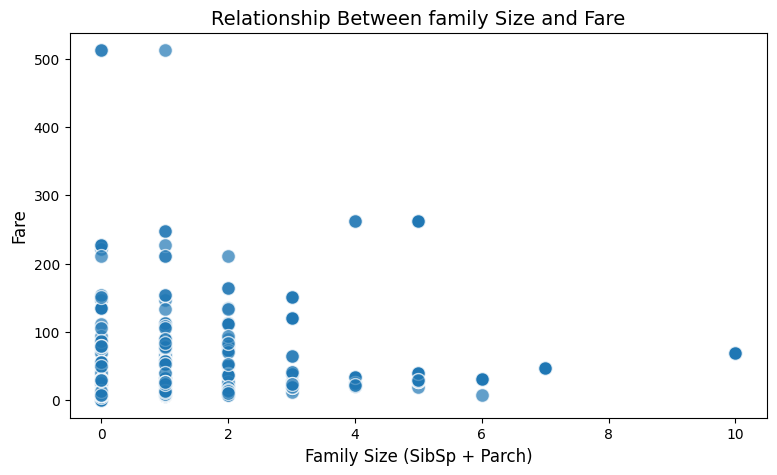

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['FamilySize'] = df['SibSp'] + df['Parch']
plt.figure(figsize=(9,5))
plt.scatter(df['FamilySize'], df['Fare'], s = 100, alpha=0.7, edgecolors = 'white', linewidth = 1)
plt.xlabel("Family Size (SibSp + Parch)", fontsize=12)
plt.ylabel("Fare", fontsize=12)
plt.title("Relationship Between family Size and Fare", fontsize=14)

plt.show()

Q6. Create a countplot to show survival count by gender.
- Females survived more compared to males despite males being majority of passengers on board.

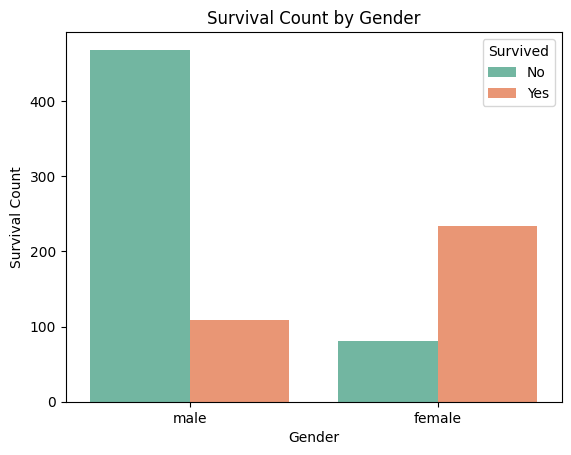

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")

sns.countplot(
    x="sex",
    hue="survived",
    data=titanic,
    palette="Set2"
)

plt.xlabel("Gender")
plt.ylabel("Survival Count")
plt.title("Survival Count by Gender")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

Q7. Create a bar chart to show survival by passenger class.
- Passengers of Class 1 has highest survival rate, followed by Class 2.
- Class 3 has lowest survival rate.


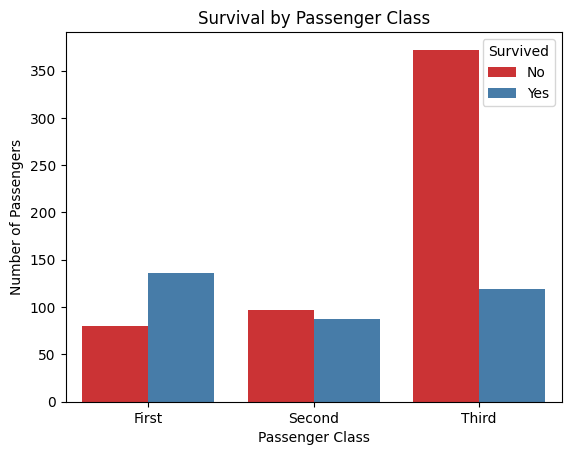

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")

sns.countplot(
    x="class",
    hue="survived",
    data=titanic,
    palette="Set1"
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Survival by Passenger Class")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

Q8. Create a heatmap to show correlation between numerical variables.
- Shows negative correlation between Passenger class and Fare.

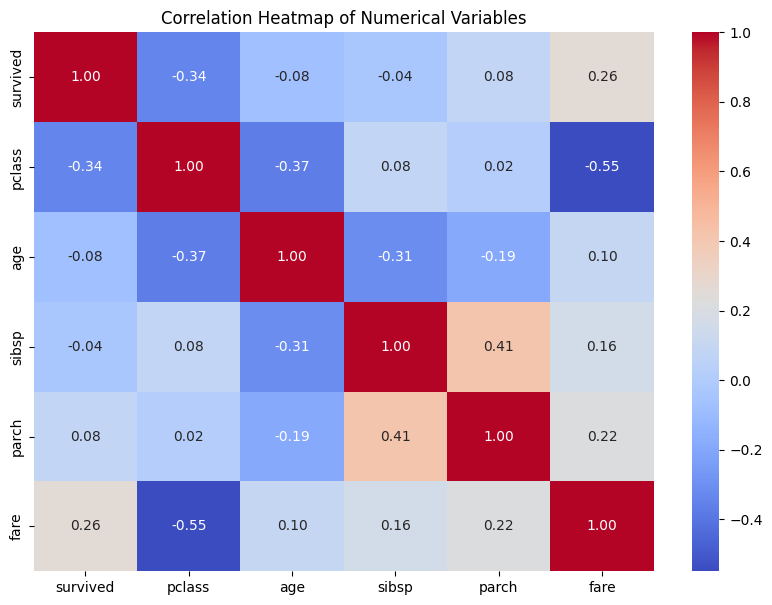

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset("titanic")

numeric_data = titanic.select_dtypes(include=["number"])

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

Q9. Identify which passenger class paid the highest fare on average.
- Passenger Class 1 paid highest fare on average.


In [ ]:
import seaborn as sns

titanic = sns.load_dataset("titanic")

average_fare = titanic.groupby("class", observed=True)["fare"].mean()

print(average_fare)

highest_class = average_fare.idxmax()

print("\nPassenger class with the highest average fare:")
print(highest_class)

class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64

Passenger class with the highest average fare:
First


Q10. Write at least 5 insights from the dataset based on your visualizations.

- From the countplot of gender, the number of male passengers is  higher than female passengers.
- From the bar chart and fare analysis, First class passengers paid the highest average fare, followed by Second class, while Third class paid the least.
- The survival countplot by gender shows that females had a much higher survival count compared to males, even though males were more in number.
- From survival vs class visualization, First-class passengers survived more often than Second and Third class passengers, indicating priority rescue based on class.
- From the age histogram and age-vs-fare scatterplot:

   Most passengers were between 20–40 years old
   
   There is no strong linear relationship between age and fare, meaning ticket price was not based on age.